# Exercise 2

## Students

This report was prepared by the following students:

- **Student 1**: Abdulghani Almasri
- **Student 2**: Alvaro Garmendia

## 2.1 Barrier Synchronization

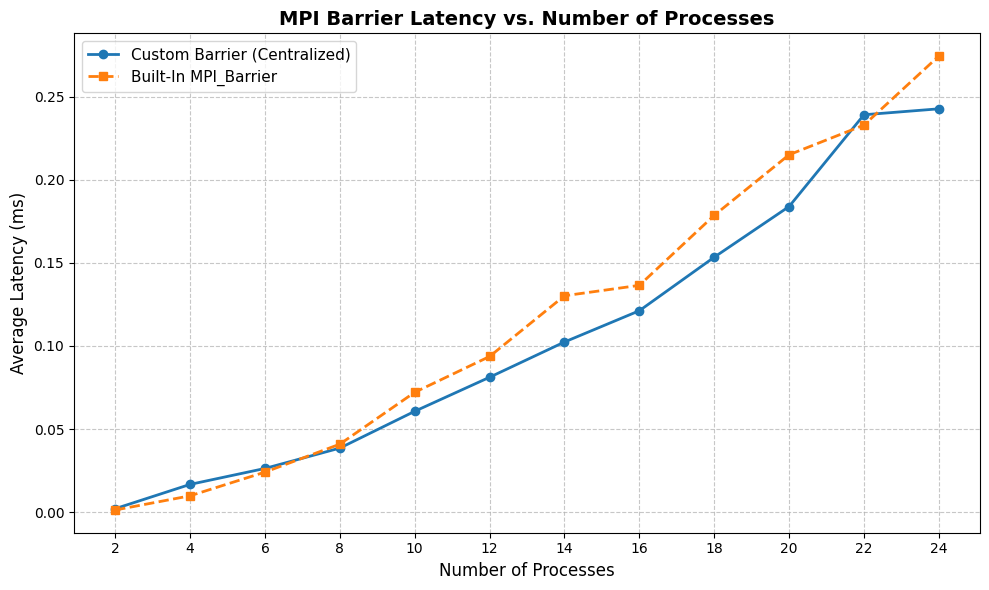

### Benchmark Results

| Processes | Custom Latency (ms) | Built-In Latency (ms) |
| :---: | :---: | :---: |
| 2 | 0.002086 | 0.001280 |
| 4 | 0.016702 | 0.009832 |
| 6 | 0.026302 | 0.024091 |
| 8 | 0.038555 | 0.040911 |
| 10 | 0.060696 | 0.072129 |
| 12 | 0.081184 | 0.093682 |
| 14 | 0.102391 | 0.130224 |
| 16 | 0.121215 | 0.136494 |
| 18 | 0.153428 | 0.178610 |
| 20 | 0.183923 | 0.215082 |
| 22 | 0.239156 | 0.232937 |
| 24 | 0.242731 | 0.274499 |




### Explanation of the Results

When analyzing these numbers, there are two major takeaways. 

**1. The General Trend (Scaling Costs)**
As expected, the latency for both barrier implementations increases as the number of processes increases. With 2 processes, the custom barrier takes only ~0.002 ms, but with 24 processes, it takes ~0.242 ms. This confirms that synchronization is expensive, and adding more workers to a parallel program increases the wait time at barriers.

**2. The Anomaly: The Custom Barrier wins!**
Looking at the data from 8 processes onward, the highly-optimized built-in MPI barrier actually starts losing to the unoptimized custom barrier. At 24 processes, the custom barrier took 0.242 ms, while the built-in barrier took 0.274 ms. 

This happens because of the following reasons:
* **Oversubscription and Busy-Waiting:** The built-in `MPI_Barrier` is designed to be hyper-fast on physical networks, so it often uses "busy-waiting" (spinning the CPU in an infinite loop waiting for messages). Because the script forces up to 24 processes to share a smaller number of physical CPU cores on a single node (`--oversubscribe`), the built-in barrier causes the processes to fight each other for CPU time, leading to severe thrashing.
* **The "Traffic Light" Effect:** The custom centralized barrier forces all workers to sequentially talk to Rank 0. While mathematically inefficient on a large network ($O(N)$), on a single oversubscribed computer, it inadvertently acts as a strict traffic controller. It stops the processes from fighting all at once, which ironically results in less CPU thrashing and a slightly faster overall time in this specific environment.

To see the built-in barrier's true $O(\log N)$ superiority, we would need to run this benchmark across multiple physical nodes without oversubscribing the CPU cores.

## 2.2 Barrier Synchronization

### 2.2.1 Naive Implementation

**Execution time:** 44.078872 seconds

**Achieved Performance:** 0.389753 GFLOP/s

The huge gap between achieved and theoretical peak GFLOP/s is caused by the **Memory Subsystem** (specifically RAM bandwidth and CPU Cache misses). The program is heavily memory-bound, not compute-bound.

**The Root Cause (Poor Spatial Locality):**
1. **Row-Major Layout:** C/C++ stores 2D arrays row by row. Elements in the same column are physically far apart in memory (e.g., 16,384 bytes apart for $N=2048$).
2. **Column-wise Access:** The naive $i-j-k$ loop accesses matrix `B` by column (`B[k * N + j]`).
3. **Cache Misses:** When the CPU fetches a chunk of memory (a cache line), it only uses one number before jumping thousands of bytes away for the next calculation. It throws away the rest of the cache line and stalls to wait for slow RAM.



### 2.2.2 Optimized Implementation

**Execution time:** 4.009375 seconds

**Achieved Performance:** 4.284925 GFLOP/s

By changing the loop order from $i-j-k$ to $i-k-j$, the program achieved an **~11x speedup** (jumping from 0.39 GFLOP/s to 4.28 GFLOP/s). 

**Why this works:**
* **Perfect Spatial Locality:** The innermost loop now iterates over $j$ (the columns). Matrix `B` is accessed as `B[k * N + j]`, which moves strictly sequentially through memory.
* **Maximized Cache Efficiency:** Because C/C++ stores matrices in row-major order, the CPU is now reading the data exactly as it is physically laid out in RAM. 
* **Eliminated Cache Misses:** When the CPU fetches a 64-byte cache line from RAM, it now uses every single floating-point number in that block before needing to fetch the next one.
* **Unblocking the CPU:** The processor no longer spends 99% of its time stalling and waiting for slow RAM. It is now being fed data fast enough to perform continuous mathematical operations.

### 2.3 Willingness to present

* Barrier Synchronization (Section: 2.1)
* Matrix multiply - sequential version (Section: 2.2)